In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("battery.csv")
df.head()

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
0,Free Fire,iOS,86,90,53,40,13
1,Asphalt 9,Android,15,30,63,43,20
2,Free Fire,iOS,164,120,80,50,30
3,Call of Duty,Android,15,45,64,41,23
4,BGMI,iOS,174,30,75,56,19


In [3]:
df["Battery_Drain_%"] = df["Battery_Start_%"] - df["Battery_End_%"]
df.head()

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%,Battery_Drain_%
0,Free Fire,iOS,86,90,53,40,13,13
1,Asphalt 9,Android,15,30,63,43,20,20
2,Free Fire,iOS,164,120,80,50,30,30
3,Call of Duty,Android,15,45,64,41,23,23
4,BGMI,iOS,174,30,75,56,19,19


In [4]:
df = df.dropna()
df.isnull().sum()

Game_Name               0
Device_Type             0
Session_Time_Minutes    0
FPS                     0
Battery_Start_%         0
Battery_End_%           0
Battery_Drop_%          0
Battery_Drain_%         0
dtype: int64

In [5]:
X = df[["Game_Name", "Device_Type", "Session_Time_Minutes", "FPS", "Battery_Start_%"]]
y = df["Battery_Drain_%"]

In [6]:
categorical_features = ["Game_Name", "Device_Type"]
numeric_features = ["Session_Time_Minutes", "FPS", "Battery_Start_%"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [7]:
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [10]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([800, 10])
torch.Size([800, 1])
torch.Size([200, 10])
torch.Size([200, 1])


In [11]:
class BatteryDrainNN(nn.Module):
    def __init__(self, input_size):
        super(BatteryDrainNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
input_size = X_train_tensor.shape[1]

model = BatteryDrainNN(input_size)

In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 100
losses = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train_tensor)

    loss = criterion(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 611.4437
Epoch [20/100], Loss: 604.2268
Epoch [30/100], Loss: 591.8734
Epoch [40/100], Loss: 570.1732
Epoch [50/100], Loss: 532.8102
Epoch [60/100], Loss: 472.2068
Epoch [70/100], Loss: 383.7947
Epoch [80/100], Loss: 273.7471
Epoch [90/100], Loss: 169.8095
Epoch [100/100], Loss: 117.6402


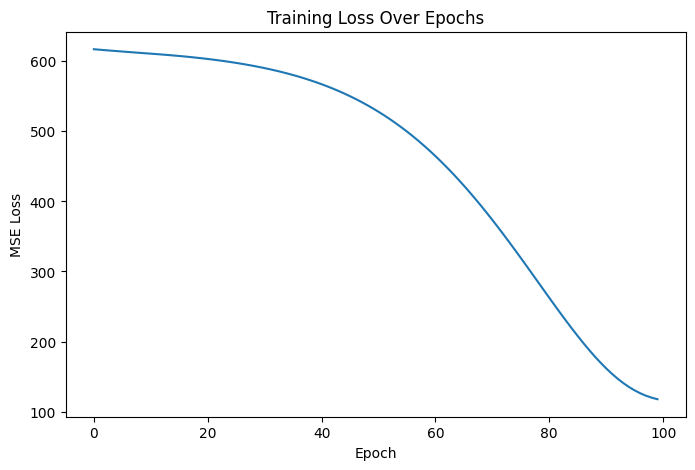

In [15]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [16]:
model.eval()

with torch.no_grad():
    y_pred_test = model(X_test_tensor)

In [17]:
y_pred_np = y_pred_test.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

In [18]:
mae = mean_absolute_error(y_test_np, y_pred_np)
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_np)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 8.621434211730957
RMSE: 10.329848245279686
R2 Score: -0.09907388687133789


In [19]:
results = pd.DataFrame({
    "Actual Battery Drain": y_test_np,
    "Predicted Battery Drain": y_pred_np
})

results.head(10)

,Actual Battery Drain,Predicted Battery Drain
0,25.0,18.571051
1,16.0,20.077250
2,37.0,21.916077
3,24.0,15.565845
4,38.0,29.461538
5,40.0,19.189289
6,28.0,18.976547
7,37.0,22.845886
8,33.0,21.601526
9,19.0,16.476734


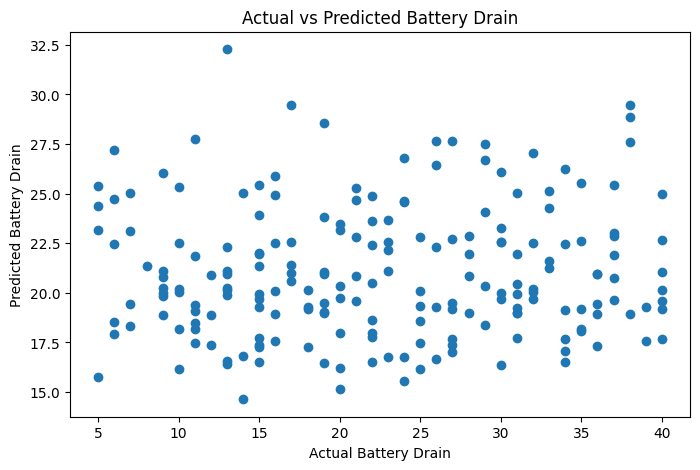

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_np, y_pred_np)
plt.xlabel("Actual Battery Drain")
plt.ylabel("Predicted Battery Drain")
plt.title("Actual vs Predicted Battery Drain")
plt.show()

In [22]:
new_data = pd.DataFrame({
    "Game_Name": ["PUBG"],
    "Device_Type": ["Android"],
    "Session_Time_Minutes": [60],
    "FPS": [60],
    "Battery_Start_%": [90]
})

In [23]:
new_data_processed = preprocessor.transform(new_data)

if hasattr(new_data_processed, "toarray"):
    new_data_processed = new_data_processed.toarray()

In [24]:
new_data_tensor = torch.tensor(new_data_processed, dtype=torch.float32)

In [25]:
model.eval()

with torch.no_grad():
    predicted_drain = model(new_data_tensor).item()

predicted_end_battery = new_data["Battery_Start_%"][0] - predicted_drain

print("Predicted Battery Drain:", predicted_drain)
print("Predicted Ending Battery:", predicted_end_battery)

Predicted Battery Drain: 17.768457412719727
Predicted Ending Battery: 72.23154258728027
